In [1]:
import pickle
import numpy as np
import librosa
import torch
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import copy
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.optim import Adam


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
def extract_feature(data, sr, mfcc, chroma, mel):
    if chroma:                          
        stft = np.abs(librosa.stft(data))  
    result = np.array([])
    if mfcc:                          
        mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
        result = np.hstack((result, mfccs))
    if chroma:                          
        chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T,axis=0)
        result = np.hstack((result, chroma))
        
    if mel:           
        mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T,axis=0)
        result = np.hstack((result, mel))
        
    return result 

In [4]:
with open("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Data/data_processing/Audio/subject_05_aud.pkl", "rb") as f:
    data_aud = pickle.load(f)

with open("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Data/data_processing/EEG/subject_05_eeg.pkl", "rb") as f:
    data_eeg = pickle.load(f)

In [5]:
# Unpack data into training and testing features and labels
X_train_aud, y_train_aud, X_test_aud, y_test_aud = data_aud
X_train_eeg, y_train_eeg, X_test_eeg, y_test_eeg = data_eeg

In [6]:
X_train_aud = np.array([extract_feature(s, sr=16000, mfcc=True, chroma=True, mel=True) for s in X_train_aud])
X_test_aud = np.array([extract_feature(s, sr=16000, mfcc=True, chroma=True, mel=True) for s in X_test_aud])

/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
X_train_aud = torch.tensor(X_train_aud).unsqueeze(1).float()
y_train_aud = torch.tensor(y_train_aud)
X_test_aud = torch.tensor(X_test_aud).unsqueeze(1).float()
y_test_aud = torch.tensor(y_test_aud)

In [8]:
X_train_eeg = torch.tensor(X_train_eeg).float().unsqueeze(1)
X_test_eeg = torch.tensor(X_test_eeg).float().unsqueeze(1)


In [9]:
emotions = ["Neutral", "Sadness", "Anger", "Happiness", "Calmness"]

## Define Data Loader

In [10]:
class PairedModalDataset(Dataset):
    def __init__(self, X_eeg, X_audio, y):
        assert len(X_eeg) == len(X_audio) == len(y)
        self.X_eeg = torch.tensor(X_eeg, dtype=torch.float32)
        self.X_audio = torch.tensor(X_audio, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_eeg[idx], self.X_audio[idx], self.y[idx]

In [11]:
batch_size = 32
y_train = np.array(y_train_aud)

# Paired loaders (used by fusion stages)
train_ds = PairedModalDataset(X_train_eeg, X_train_aud, y_train)
test_ds = PairedModalDataset(X_test_eeg, X_test_aud, y_test_aud)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=True)

# Uni-modal loaders matching paper code settings
audio_batch_size = 64
eeg_batch_size = 32

y_train_audio_t = y_train_aud.long() if torch.is_tensor(y_train_aud) else torch.tensor(y_train_aud, dtype=torch.long)
y_test_audio_t = y_test_aud.long() if torch.is_tensor(y_test_aud) else torch.tensor(y_test_aud, dtype=torch.long)
y_train_eeg_t = torch.tensor(y_train_eeg, dtype=torch.long)
y_test_eeg_t = torch.tensor(y_test_eeg, dtype=torch.long)

# CNN_audio
X_train_aud_ref = X_train_aud
X_test_aud_ref = X_test_aud
X_train_eeg_ref = X_train_eeg
X_test_eeg_ref = X_test_eeg

audio_train_loader = DataLoader(TensorDataset(X_train_aud_ref, y_train_audio_t), batch_size=audio_batch_size, shuffle=True)
audio_test_loader = DataLoader(TensorDataset(X_test_aud_ref, y_test_audio_t), batch_size=audio_batch_size, shuffle=True)

# EEGNet
eeg_train_loader = DataLoader(TensorDataset(X_train_eeg_ref, y_train_eeg_t), batch_size=eeg_batch_size, shuffle=True)
eeg_test_loader = DataLoader(TensorDataset(X_test_eeg_ref, y_test_eeg_t), batch_size=eeg_batch_size, shuffle=True)


/tmp/ipykernel_2994569/1497216861.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_train = np.array(y_train_aud)
/tmp/ipykernel_2994569/1108307568.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X_eeg = torch.tensor(X_eeg, dtype=torch.float32)
/tmp/ipykernel_2994569/1108307568.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X_audio = torch.tensor(X_audio, dtype=torch.float32)
/tmp/ipykernel_2994569/1108307568

In [12]:
X_test_eeg_ref.shape

torch.Size([120, 1, 30, 500])

## Models

EEGNet + AudioSCNN backbones feed CoGCN (one view per modality).


In [13]:
class FusionLateHead(nn.Module):
    def __init__(self, eeg_model, audio_model, num_classes, hidden=256, p_drop=0.2):
        super().__init__()
        self.eeg = eeg_model
        self.audio = audio_model

        # Freeze experts
        for p in self.eeg.parameters():   p.requires_grad = False
        for p in self.audio.parameters(): p.requires_grad = False
        self.eeg.eval()
        self.audio.eval()

        in_dim = self.eeg.dense.in_features + self.audio.classifier.in_features
        self.head = nn.Linear(in_dim, num_classes)

    def forward(self, x_eeg, x_audio):
        logits_eeg, feat_eeg = self.eeg(x_eeg, return_features=True)
        logits_audio, feat_audio = self.audio(x_audio, return_features=True)
        fused_in = torch.cat([feat_eeg, feat_audio], dim=1)
        out = self.head(fused_in)                                  # [B, C]
        return out, logits_eeg, logits_audio


In [14]:
from models import EEGNet, EEGNet_tor, AudioSCNN, CoGCN
from util import construct_graph, sparse_mx_to_torch_sparse_tensor

n_class = len(emotions)

eeg_backbone = EEGNet_tor(
    nb_classes=n_class,
    Samples=500,
    Chans=30,
    dropoutRate=0.5,
    kernLength=300,
    F1=8,
    D=8,
    F2=16,
).to(device)
optim_eeg = Adam(eeg_backbone.parameters(), lr=1e-3)
criterion_eeg = nn.CrossEntropyLoss()

aud_backbone = AudioSCNN(num_classes=n_class).to(device)
optim_aud = Adam(aud_backbone.parameters(), lr=1e-3, weight_decay=1e-6)
criterion_aud = nn.CrossEntropyLoss()


## Train Backbone Models Separately

In [15]:
def train_audio(model, optimizer, criterion, train_loader, test_loader, epochs=100, device='cpu'):
    model.to(device)
    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct, train_total = 0, 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (out.argmax(dim=1) == y).sum().item()
            train_total += y.size(0)

        train_acc = 100 * train_correct / train_total
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_acc / 100.0)

        model.eval()
        test_correct, test_total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                y = y.to(device)

                out = model(x)
                test_correct += (out.argmax(dim=1) == y).sum().item()
                test_total += y.size(0)

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss / len(train_loader):.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
        )

    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            out = model(x)
            all_preds.extend(out.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    final_test_acc = accuracy_score(all_labels, all_preds)
    final_test_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"Final Test Accuracy = {final_test_acc * 100:.2f}%")
    print(f"Final Test F1 = {final_test_f1:.4f}")

    return model, train_losses, train_accuracies, final_test_acc, final_test_f1


In [16]:
def train_eeg(model, optimizer, criterion, train_loader, test_loader, epochs=100, device='cpu'):
    model.to(device)
    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).long()

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = outputs.argmax(dim=1)

            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_acc = 100 * train_correct / train_total

        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_acc / 100.0)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss/len(train_loader):.4f} | "
            f"Train Acc: {train_acc:.4f} | "
        )
    
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).long()
            outputs = model(inputs)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    final_test_acc = accuracy_score(all_labels, all_preds)
    final_test_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"Final Test Accuracy = {final_test_acc * 100:.2f}%")
    print(f"Final Test F1 = {final_test_f1:.4f}")
    return model, train_losses, train_accuracies, final_test_acc, final_test_f1


In [17]:
def train_fusion(model, optimizer, criterion, train_loader, test_loader, epochs=100, device="cpu"):
    # using test set as validation here
    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        # Training
        model.train()
        train_epoch_loss = 0
        train_correct = 0
        train_total = 0
        for eeg, audio, labels in train_loader:
            eeg = eeg.to(dtype=torch.float32, device=device)
            audio = audio.to(dtype=torch.float32, device=device)
            labels = labels.to(device=device)

            optimizer.zero_grad()
            outputs, _, _ = model(eeg, audio)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_epoch_loss += loss.item()

            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.numel()

        train_epoch_loss = train_epoch_loss / len(train_loader)
        train_epoch_acc = train_correct / train_total if train_total else 0.

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_acc)

    
        print(f"Epoch {epoch+1} |"
              f"Train Loss: {train_epoch_loss:.3f} |"
              f"Train Acc: {train_epoch_acc * 100 :.2f}%")

    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for eeg, audio, labels in test_loader:
            eeg = eeg.to(dtype=torch.float32, device=device)
            audio = audio.to(dtype=torch.float32, device=device)
            labels = labels.to(device=device)

            outputs, _, _ = model(eeg, audio)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    best_test_acc = accuracy_score(all_labels, all_preds)
    best_test_f1 = f1_score(all_labels, all_preds, average="macro")
    print(f"Final Test Accuracy = {best_test_acc * 100:.2f}%")
    print(f"Final Test F1 = {best_test_f1:.4f}")

    return model, train_losses, train_accuracies

In [18]:
print("Training Audio model (paper settings)")
aud_backbone, train_losses_aud, train_accs_aud, final_test_acc_aud, final_test_f1_aud = train_audio(
    aud_backbone,
    optim_aud,
    criterion_aud,
    audio_train_loader,
    audio_test_loader,
    epochs=100,
    device=device,
)


Training Audio model (paper settings)
Epoch [1/100] | Train Loss: 2.7702 | Train Acc: 19.29% | 
Epoch [2/100] | Train Loss: 1.6806 | Train Acc: 20.00% | 
Epoch [3/100] | Train Loss: 1.6147 | Train Acc: 21.07% | 
Epoch [4/100] | Train Loss: 1.5865 | Train Acc: 27.86% | 
Epoch [5/100] | Train Loss: 1.5010 | Train Acc: 32.86% | 
Epoch [6/100] | Train Loss: 1.4191 | Train Acc: 40.71% | 
Epoch [7/100] | Train Loss: 1.3473 | Train Acc: 46.79% | 
Epoch [8/100] | Train Loss: 1.1878 | Train Acc: 51.79% | 
Epoch [9/100] | Train Loss: 1.1339 | Train Acc: 47.50% | 
Epoch [10/100] | Train Loss: 1.1460 | Train Acc: 53.21% | 
Epoch [11/100] | Train Loss: 1.0623 | Train Acc: 47.86% | 
Epoch [12/100] | Train Loss: 1.0364 | Train Acc: 57.50% | 
Epoch [13/100] | Train Loss: 1.0084 | Train Acc: 56.07% | 
Epoch [14/100] | Train Loss: 0.9509 | Train Acc: 58.21% | 
Epoch [15/100] | Train Loss: 0.9032 | Train Acc: 63.57% | 
Epoch [16/100] | Train Loss: 0.8555 | Train Acc: 60.71% | 
Epoch [17/100] | Train Loss

In [19]:
PATH = "/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/audio_scnn.pth"
torch.save(aud_backbone.state_dict(), PATH)

In [20]:
print("Training EEGNet (paper settings)")
eeg_backbone, train_losses_eeg, train_accs_eeg, final_test_acc_eeg, final_test_f1_eeg = train_eeg(
    eeg_backbone,
    optim_eeg,
    criterion_eeg,
    eeg_train_loader,
    eeg_test_loader,
    epochs=100,
    device=device,
)


Training EEGNet (paper settings)
Epoch 1/100 | Train Loss: 1.6097 | Train Acc: 21.4286 | 
Epoch 2/100 | Train Loss: 1.5728 | Train Acc: 35.0000 | 
Epoch 3/100 | Train Loss: 1.5311 | Train Acc: 41.0714 | 


/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/venv/lib/python3.12/site-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


Epoch 4/100 | Train Loss: 1.5054 | Train Acc: 43.5714 | 
Epoch 5/100 | Train Loss: 1.4829 | Train Acc: 48.9286 | 
Epoch 6/100 | Train Loss: 1.4495 | Train Acc: 52.5000 | 
Epoch 7/100 | Train Loss: 1.4366 | Train Acc: 54.6429 | 
Epoch 8/100 | Train Loss: 1.4079 | Train Acc: 58.5714 | 
Epoch 9/100 | Train Loss: 1.3871 | Train Acc: 61.7857 | 
Epoch 10/100 | Train Loss: 1.3777 | Train Acc: 59.6429 | 
Epoch 11/100 | Train Loss: 1.3579 | Train Acc: 62.5000 | 
Epoch 12/100 | Train Loss: 1.3448 | Train Acc: 63.9286 | 
Epoch 13/100 | Train Loss: 1.3151 | Train Acc: 68.2143 | 
Epoch 14/100 | Train Loss: 1.2953 | Train Acc: 70.0000 | 
Epoch 15/100 | Train Loss: 1.2711 | Train Acc: 72.5000 | 
Epoch 16/100 | Train Loss: 1.2769 | Train Acc: 67.5000 | 
Epoch 17/100 | Train Loss: 1.2480 | Train Acc: 73.5714 | 
Epoch 18/100 | Train Loss: 1.2390 | Train Acc: 75.7143 | 
Epoch 19/100 | Train Loss: 1.2303 | Train Acc: 75.3571 | 
Epoch 20/100 | Train Loss: 1.2036 | Train Acc: 79.2857 | 
Epoch 21/100 | Train

In [21]:
PATH = "/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/eeg_cnn.pth"
torch.save(eeg_backbone.state_dict(), PATH)

In [22]:
eeg_backbone.load_state_dict(torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/eeg_cnn.pth", map_location=device))
aud_backbone.load_state_dict(torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/audio_scnn.pth", map_location=device))

<All keys matched successfully>

In [23]:
fusion = FusionLateHead(eeg_backbone, aud_backbone, num_classes=n_class, hidden=256, p_drop=0.2).to(device)
optim_fusion = torch.optim.AdamW(fusion.head.parameters(), lr=5e-4, weight_decay=1e-4)
criterion_fusion = nn.CrossEntropyLoss()

In [24]:
print("Training Fusion model")
fusion, train_losses_fusion, train_accs_fusion = train_fusion(fusion, optim_fusion, criterion_fusion, train_loader, test_loader, epochs=100, device=device)

Training Fusion model
Epoch 1 |Train Loss: 1.334 |Train Acc: 48.21%
Epoch 2 |Train Loss: 0.445 |Train Acc: 92.86%
Epoch 3 |Train Loss: 0.198 |Train Acc: 97.50%
Epoch 4 |Train Loss: 0.119 |Train Acc: 98.93%
Epoch 5 |Train Loss: 0.078 |Train Acc: 99.64%
Epoch 6 |Train Loss: 0.075 |Train Acc: 98.93%
Epoch 7 |Train Loss: 0.064 |Train Acc: 98.93%
Epoch 8 |Train Loss: 0.048 |Train Acc: 100.00%
Epoch 9 |Train Loss: 0.039 |Train Acc: 100.00%
Epoch 10 |Train Loss: 0.044 |Train Acc: 99.64%
Epoch 11 |Train Loss: 0.035 |Train Acc: 100.00%
Epoch 12 |Train Loss: 0.039 |Train Acc: 100.00%
Epoch 13 |Train Loss: 0.027 |Train Acc: 100.00%
Epoch 14 |Train Loss: 0.026 |Train Acc: 100.00%
Epoch 15 |Train Loss: 0.030 |Train Acc: 100.00%
Epoch 16 |Train Loss: 0.020 |Train Acc: 100.00%
Epoch 17 |Train Loss: 0.021 |Train Acc: 100.00%
Epoch 18 |Train Loss: 0.022 |Train Acc: 100.00%
Epoch 19 |Train Loss: 0.023 |Train Acc: 100.00%
Epoch 20 |Train Loss: 0.017 |Train Acc: 100.00%
Epoch 21 |Train Loss: 0.019 |Train 

Test acc: 85.0000 | F1-macro: 0.8518 | F1-weighted: 0.8518


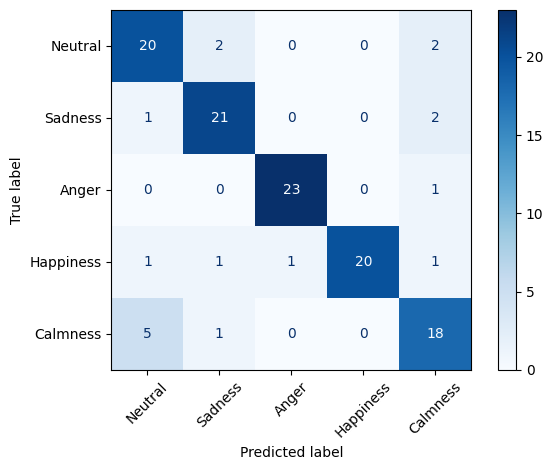

In [25]:
# Evaluate on test set
fusion.eval()

preds, _, _ = fusion(X_test_eeg.to(device), X_test_aud.to(device))
preds = preds.argmax(dim=1).cpu()

acc = accuracy_score(y_test_aud, preds) * 100
f1_macro = f1_score(y_test_aud, preds, average="macro")
f1_weighted = f1_score(y_test_aud, preds, average="weighted")
print(f"Test acc: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")

cm = confusion_matrix(y_test_aud, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=emotions)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()


## Train (Backbones + CoGCN)

We build graphs from current backbone features (detached) and train end-to-end.


### Build indices & graphs (frozen phase)


In [26]:
# Build full tensors and indices (train/val/test are contiguous blocks)
X_eeg_all = torch.cat([X_train_eeg, X_test_eeg], dim=0).to(device)
X_aud_all = torch.cat([X_train_aud, X_test_aud], dim=0).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)

y_test_t = y_test_aud.to(device).long() if torch.is_tensor(y_test_aud) else torch.tensor(y_test_aud, dtype=torch.long, device=device)
y_all = torch.cat([y_train_t, y_test_t], dim=0)

n_train = len(y_train)
n_test = len(y_test_aud)
train_idx = torch.arange(0, n_train, device=device)
test_idx = torch.arange(n_train, n_train + n_test, device=device)

# Hyperparams
lr = 1e-3
weight_decay = 5e-4
k = 10
epochs_frozen = 200

low_lr = 1e-5
epochs_finetune = 10
rebuild_epochs = {1, max(2, epochs_finetune // 2)}  # rebuild once or twice

# CoGCN params
lr_alpha = 0.01
dropout = 0.3


### Freeze backbones and build graphs once


In [27]:
eeg_backbone.load_state_dict(torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/eeg_cnn.pth", map_location=device))
aud_backbone.load_state_dict(torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Models/audio_scnn.pth", map_location=device))

<All keys matched successfully>

In [28]:
def build_graphs(feat_eeg, feat_aud, y_np, k):
    Adj0 = construct_graph(feat_eeg, targets=y_np, k=k, metric="euclidean")
    Adj1 = construct_graph(feat_aud, targets=y_np, k=k, metric="euclidean")
    return [
        sparse_mx_to_torch_sparse_tensor(Adj0).to(device),
        sparse_mx_to_torch_sparse_tensor(Adj1).to(device),
    ]

def set_requires_grad(model, flag):
    for p in model.parameters():
        p.requires_grad = flag

# Freeze backbones
set_requires_grad(eeg_backbone, False)
set_requires_grad(aud_backbone, False)
eeg_backbone.eval()
aud_backbone.eval()

with torch.no_grad():
    logits_eeg, feat_eeg = eeg_backbone(X_eeg_all, return_features=True)
    logits_aud, feat_aud = aud_backbone(X_aud_all, return_features=True)

feat_eeg = feat_eeg.detach().cpu().numpy().astype(np.float32)
feat_aud = feat_aud.detach().cpu().numpy().astype(np.float32)

adjs = build_graphs(feat_eeg, feat_aud, y_all.detach().cpu().numpy(), k)


/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/code/co-gcn/util.py:30: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  return torch.sparse.FloatTensor(indices, values, shape)


### Init CoGCN per view + optimizers


In [29]:
n_view = 2
cogcn_nets = [
    CoGCN(nfeat=feat_eeg.shape[1], nclass=n_class, adjs=adjs, n_view=n_view, lr_alpha=lr_alpha, dropout=dropout, device=device).to(device),
    CoGCN(nfeat=feat_aud.shape[1], nclass=n_class, adjs=adjs, n_view=n_view, lr_alpha=lr_alpha, dropout=dropout, device=device).to(device),
]

optimizers = [
    torch.optim.Adam(cogcn_nets[0].parameters(), lr=lr, weight_decay=weight_decay),
    torch.optim.Adam(cogcn_nets[1].parameters(), lr=lr, weight_decay=weight_decay),
]


/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/code/co-gcn/models.py:22: UserWarning: torch.sparse.SparseTensor(shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:685.)
  self.adj = torch.sparse.FloatTensor(self.n, self.n)


### Frozen phase training (per-view loss)


In [30]:
# Cache feature tensors once (backbones are frozen)
feat_eeg_t = torch.tensor(feat_eeg, device=device)
feat_aud_t = torch.tensor(feat_aud, device=device)

for epoch in range(1, epochs_frozen + 1):
    # train each view separately
    for v in range(n_view):
        cogcn_nets[v].train()
        optimizers[v].zero_grad()
        out_v = cogcn_nets[v](feat_eeg_t if v == 0 else feat_aud_t)
        loss = F.nll_loss(out_v[train_idx], y_all[train_idx])
        loss.backward()
        optimizers[v].step()
        cogcn_nets[v].gc1.update_alpha()
        cogcn_nets[v].gc2.update_alpha()

    # ensemble eval (train/val only)
    for v in range(n_view):
        cogcn_nets[v].eval()
    with torch.no_grad():
        out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

    pred = out_sum.argmax(dim=1)
    train_acc = (pred[train_idx] == y_all[train_idx]).float().mean().item()
    test_acc = (pred[test_idx] == y_all[test_idx]).float().mean().item()


    if epoch % 20 == 0 or epoch == 1:
        print(f"[Frozen] Epoch {epoch:03d} Train accuracy = {train_acc * 100 :.2f}% Test accuracy = {test_acc * 100 :.2f}%")


[Frozen] Epoch 001 Train accuracy = 36.07% Test accuracy = 40.83%
[Frozen] Epoch 020 Train accuracy = 100.00% Test accuracy = 79.17%
[Frozen] Epoch 040 Train accuracy = 100.00% Test accuracy = 84.17%
[Frozen] Epoch 060 Train accuracy = 100.00% Test accuracy = 81.67%
[Frozen] Epoch 080 Train accuracy = 100.00% Test accuracy = 83.33%
[Frozen] Epoch 100 Train accuracy = 100.00% Test accuracy = 83.33%
[Frozen] Epoch 120 Train accuracy = 100.00% Test accuracy = 83.33%
[Frozen] Epoch 140 Train accuracy = 100.00% Test accuracy = 84.17%
[Frozen] Epoch 160 Train accuracy = 100.00% Test accuracy = 84.17%
[Frozen] Epoch 180 Train accuracy = 100.00% Test accuracy = 84.17%
[Frozen] Epoch 200 Train accuracy = 100.00% Test accuracy = 84.17%


Test acc: 84.1667 | F1-macro: 0.8413 | F1-weighted: 0.8413


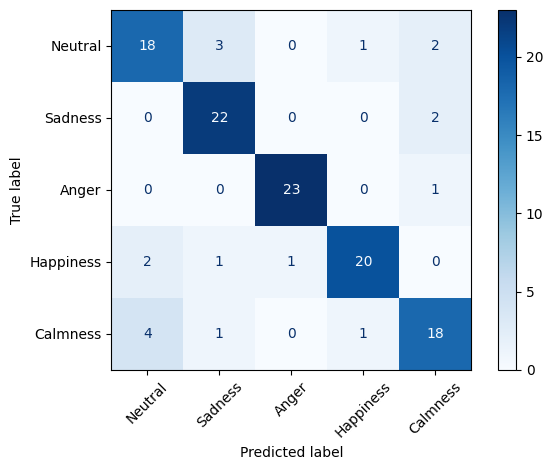

In [31]:
# Evaluate on test set
eeg_backbone.eval()
aud_backbone.eval()
for net in cogcn_nets:
    net.eval()

with torch.no_grad():
    _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
    _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)
    out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

y_true = y_all[test_idx].cpu().numpy()
y_pred = out_sum[test_idx].argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_true, y_pred) * 100
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")
print(f"Test acc: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=emotions)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()


### Fine-tune (unfreeze backbones, low LR)


In [32]:
# Unfreeze backbones
set_requires_grad(eeg_backbone, True)
set_requires_grad(aud_backbone, True)

# Single optimizer over all params (backbones + CoGCN nets)
params = list(eeg_backbone.parameters()) + list(aud_backbone.parameters())
for net in cogcn_nets:
    params += list(net.parameters())
opt = torch.optim.Adam(params, lr=low_lr, weight_decay=weight_decay)
print(len(params))


for epoch in range(1, epochs_finetune + 1):
    eeg_backbone.train()
    aud_backbone.train()
    for net in cogcn_nets:
        net.train()

    _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
    _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)

    # Rebuild graphs once or twice using updated features
    if epoch % 10 == 0:
        adjs = build_graphs(
            feat_eeg_t.detach().cpu().numpy().astype(np.float32),
            feat_aud_t.detach().cpu().numpy().astype(np.float32),
            y_all.detach().cpu().numpy(),
            k,
        )
        for net in cogcn_nets:
            net.gc1.adjs = adjs
            net.gc2.adjs = adjs
            net.gc1._update_adj()
            net.gc2._update_adj()

    # Per-view losses, summed (graphs fixed between rebuilds)
    out_v0 = cogcn_nets[0](feat_eeg_t)
    out_v1 = cogcn_nets[1](feat_aud_t)
    loss = F.nll_loss(out_v0[train_idx], y_all[train_idx]) + \
            F.nll_loss(out_v1[train_idx], y_all[train_idx])

    opt.zero_grad()
    loss.backward()
    opt.step()

    for net in cogcn_nets:
        net.gc1.update_alpha()
        net.gc2.update_alpha()

    # Ensemble eval (train/val only)
    eeg_backbone.eval()
    aud_backbone.eval()
    for net in cogcn_nets:
        net.eval()
    with torch.no_grad():
        _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
        _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)
        out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

    pred = out_sum.argmax(dim=1)
    train_acc = (pred[train_idx] == y_all[train_idx]).float().mean().item()
    test_acc = (pred[test_idx] == y_all[test_idx]).float().mean().item()

    if epoch % 10 == 0 or epoch == 1:
        print(f"[Finetune] Epoch {epoch:03d} Train loss {loss.item():.4f} Train accuracy = {train_acc * 100 :.2f}% Test accuracy = {test_acc * 100 :.2f}%")

29
[Finetune] Epoch 001 Train loss 0.3125 Train accuracy = 100.00% Test accuracy = 84.17%
[Finetune] Epoch 010 Train loss 0.4875 Train accuracy = 100.00% Test accuracy = 85.00%


### Test metrics (accuracy, F1, confusion matrix)


Test acc: 85.0000 | F1-macro: 0.8503 | F1-weighted: 0.8503


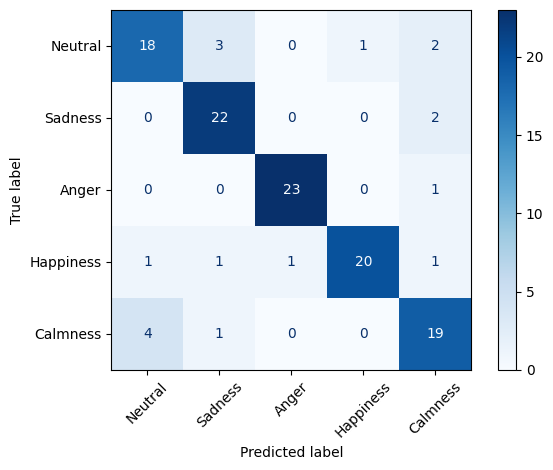

In [33]:
# Evaluate on test set
eeg_backbone.eval()
aud_backbone.eval()
for net in cogcn_nets:
    net.eval()

with torch.no_grad():
    _, feat_eeg_t = eeg_backbone(X_eeg_all, return_features=True)
    _, feat_aud_t = aud_backbone(X_aud_all, return_features=True)
    out_sum = cogcn_nets[0](feat_eeg_t) + cogcn_nets[1](feat_aud_t)

y_true = y_all[test_idx].cpu().numpy()
y_pred = out_sum[test_idx].argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_true, y_pred) * 100
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")
print(f"Test acc: {acc:.4f} | F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=emotions)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()
